## 1. Import thư viện và tải dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Thư viện đã được import thành công!')


Thư viện đã được import thành công!


In [2]:
# Tải bộ dữ liệu Communities and Crime Unnormalized (ID = 211)
communities_and_crime_unnormalized = fetch_ucirepo(id=211)
df_raw = communities_and_crime_unnormalized.data.original

print(f'Kích thước dữ liệu gốc: {df_raw.shape[0]} dòng × {df_raw.shape[1]} cột')
df_raw.head()

Kích thước dữ liệu gốc: 2215 dòng × 147 cột


,communityname,State,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,35.0,29443.0,1,16656,2.40,1.70,97.35,0.50,...,225.0,1301.78,716.0,4142.56,47.0,271.93,NaN,NaN,306.64,NaN
4,Bemidjicity,MN,7.0,5068.0,1,11245,2.76,0.53,89.16,1.17,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,NaN,9988.79


## 2. Tiền xử lý dữ liệu (Data Preprocessing)

In [9]:
df_clean = df_raw.copy()

print('=== THÔNG TIN DỮ LIỆU TRƯỚC XỬ LÝ ===')
print(f'Số dòng ban đầu: {df_clean.shape[0]}')
print(f'Số biến: {df_clean.shape[1]}')
print(f'\nCác cột có giá trị khuyết (Missing values):')
missing = df_clean.isnull().sum()
print(missing[missing > 0])

# --- 1. Loại bỏ các cột có tỷ lệ khuyết > 50% ---
missing_percent = df_clean.isnull().mean() * 100
cols_missing_over_50 = missing_percent[missing_percent > 50].index
df_clean = df_clean.drop(columns=cols_missing_over_50)
print(f'Đã loại bỏ {len(cols_missing_over_50)} cột do thiếu > 50% dữ liệu.')

# --- 2. Xóa hàng thiếu biến mục tiêu ---
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['violentPerPop'])
print(f'Đã xóa {rows_before - len(df_clean)} hàng do thiếu giá trị biến mục tiêu.')

# --- 3. Điền Median cho các biến số còn lại ---
feature_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('violentPerPop')
df_clean[feature_cols] = df_clean[feature_cols].fillna(df_clean[feature_cols].median())

crime_cols = [
    'murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
    'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
    'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop', 'nonViolPerPop'
]

df_clean = df_clean.drop(columns=[c for c in crime_cols if c in df_clean.columns])

print('\n=== THÔNG TIN DỮ LIỆU SAU XỬ LÝ ===')
print(f'Số dòng để phân tích: {df_clean.shape[0]}')
print(f'Kiểm tra lại missing values: {df_clean.isnull().sum().sum()}')


=== THÔNG TIN DỮ LIỆU TRƯỚC XỬ LÝ ===
Số dòng ban đầu: 2215
Số biến: 147

Các cột có giá trị khuyết (Missing values):
countyCode           1221
communityCode        1224
otherPerCap             1
numPolice            1872
policePerPop         1872
policeField          1872
policeFieldPerPop    1872
policeCalls          1872
policCallPerPop      1872
policCallPerOffic    1872
policePerPop2        1872
racialMatch          1872
pctPolicWhite        1872
pctPolicBlack        1872
pctPolicHisp         1872
pctPolicAsian        1872
pctPolicMinority     1872
officDrugUnits       1872
numDiffDrugsSeiz     1872
policAveOT           1872
policCarsAvail       1872
policOperBudget      1872
pctPolicPatrol       1872
gangUnit             1872
policBudgetPerPop    1872
rapes                 208
rapesPerPop           208
robberies               1
robbbPerPop             1
assaults               13
assaultPerPop          13
burglaries              3
burglPerPop             3
larcenies               

## 3. Thống kê Mô tả (Descriptive Statistics)

In [14]:
# Thống kê mô tả các biến độc lập cần phân tích
key_vars = ['violentPerPop', 'pct12-29', 'pctCollGrad',
            'pctPoverty', 'medIncome', 'pctKidsBornNevrMarr', 'pctKids2Par']

key_vars = [v for v in key_vars if v in df_clean.columns]

desc = df_clean[key_vars].describe().round(2)
print('=== THỐNG KÊ MÔ TẢ CÁC BIẾN CHÍNH ===')
print(desc)

# Thêm Skewness và Kurtosis
print('\nĐộ lệch (Skewness):')
print(df_clean[key_vars].skew().round(3))
print('\nĐộ nhọn (Kurtosis):')
print(df_clean[key_vars].kurtosis().round(3))

=== THỐNG KÊ MÔ TẢ CÁC BIẾN CHÍNH ===
       violentPerPop  pct12-29  pctCollGrad  pctPoverty  medIncome  \
count        1994.00   1994.00      1994.00     1994.00    1994.00   
mean          589.08     27.62        22.99       11.80   33699.33   
std           614.78      6.15        12.51        8.51   13391.74   
min             0.00      9.38         1.63        0.64   11576.00   
25%           161.70     24.38        14.09        4.69   23597.00   
50%           374.06     26.76        19.62        9.65   30896.00   
75%           794.40     29.18        28.94       17.08   41214.75   
max          4877.06     70.51        73.63       48.82  123625.00   

       pctKidsBornNevrMarr  pctKids2Par  
count              1994.00      1994.00  
mean                  3.14        70.91  
std                   3.07        11.85  
min                   0.00        26.11  
25%                   1.08        63.62  
50%                   2.08        72.06  
75%                   3.98        79.

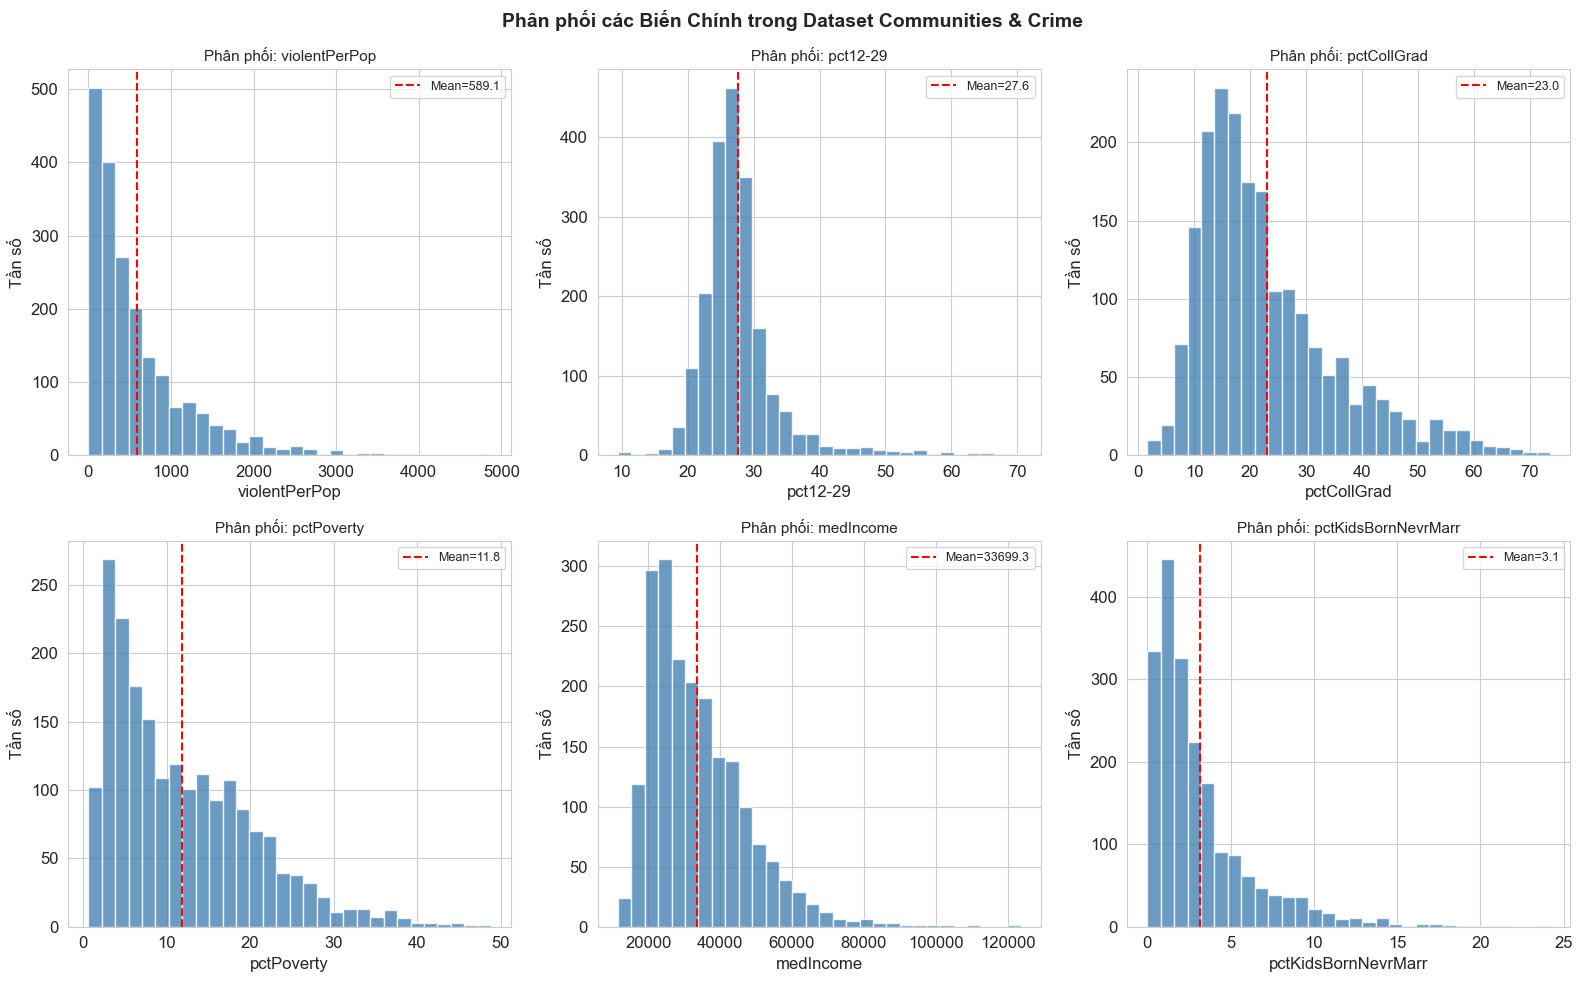

Biểu đồ 1: Phân phối các biến


In [13]:
# Biểu đồ phân phối của biến mục tiêu
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars[:6]):
    if var in df_clean.columns:
        axes[i].hist(df_clean[var].dropna(), bins=30, color='steelblue', 
                     edgecolor='white', alpha=0.8)
        axes[i].set_title(f'Phân phối: {var}', fontsize=11)
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Tần số')
        # Thêm đường mean
        axes[i].axvline(df_clean[var].mean(), color='red', linestyle='--', 
                        label=f'Mean={df_clean[var].mean():.1f}')
        axes[i].legend(fontsize=9)

plt.suptitle('Phân phối các Biến Chính trong Dataset Communities & Crime', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()


print('Biểu đồ 1: Phân phối các biến')

### Nhận xét biểu đồ phân phối:
1. Tỷ lệ tội phạm bạo lực (violentPerPop)
Phân phối lệch phải rất mạnh. Đa số các cộng đồng có tỷ lệ tội phạm thấp, nhưng vẫn tồn tại một nhóm nhỏ các "điểm nóng" với mức độ bạo lực cực kỳ cao (phần đuôi kéo dài).
2. Tỷ lệ thanh niên 12-29 tuổi (pct12-29)
Phân phối tương đối đối xứng, tập trung nhiều nhất quanh mức 25-30%. Các cộng đồng có tỷ lệ thanh niên quá thấp hoặc quá cao đều xuất hiện với tần suất rất ít.
3. Tỷ lệ tốt nghiệp Đại học (pctCollGrad)
Phân phối lệch phải rõ rệt. Phần lớn cộng đồng có tỷ lệ cử nhân ở mức thấp đến trung bình (khoảng 15-20%), rất hiếm khu vực có tỷ lệ trí thức cao vượt trội.
4. Tỷ lệ hộ nghèo (pctPoverty)
Phân phối lệch phải. Hầu hết các cộng đồng duy trì tỷ lệ nghèo ở mức thấp, số lượng cộng đồng giảm dần khi mức độ nghèo đói tăng cao.
5. Thu nhập trung vị (medIncome)
Phân phối có dạng gần hình chuông nhưng hơi lệch phải nhẹ. Phần lớn khu vực tập trung quanh mức thu nhập trung bình, kèm theo một nhóm thiểu số các cộng đồng có thu nhập rất cao.
6. Trẻ sinh ra ngoài giá thú (pctKidsBornNevrMarr)
Phân phối lệch phải mạnh. Đa số cộng đồng có tỷ lệ trẻ sinh ra ngoài giá thú thấp (dưới 2%), nhưng vẫn có những khu vực cá biệt tỷ lệ này lên tới 8-10%.

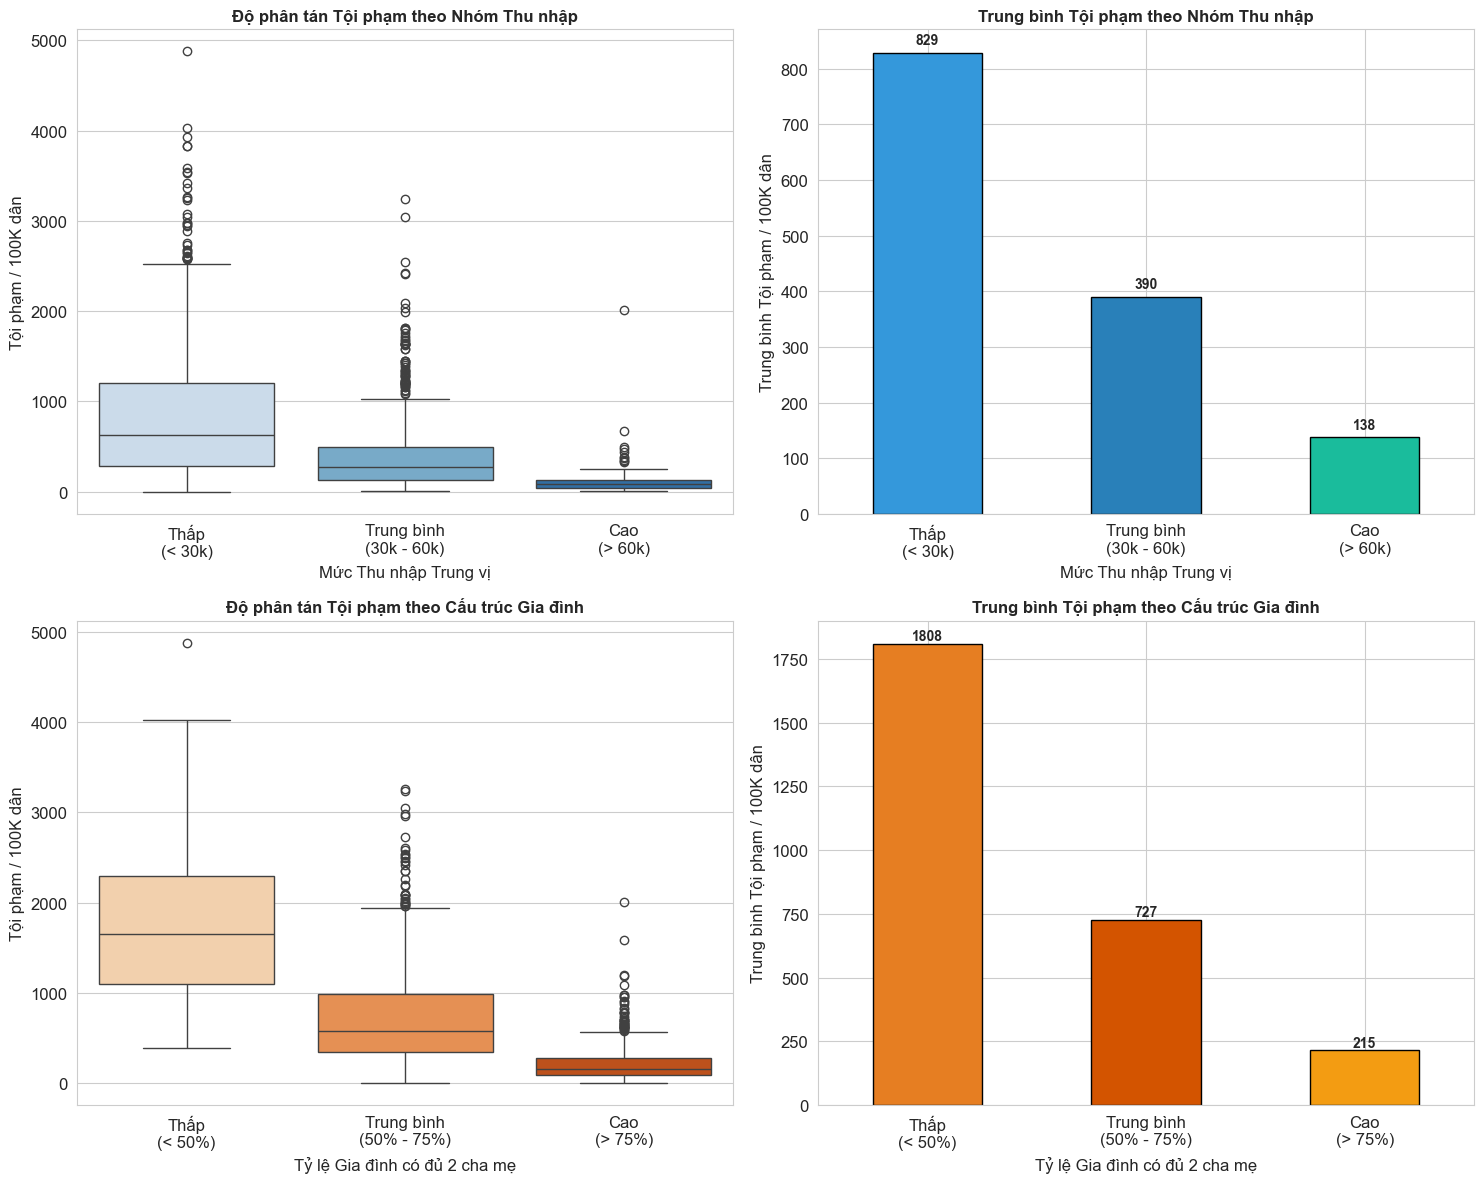

Biểu đồ 2: So sánh Tỷ lệ tội phạm theo Thu nhập và Cấu trúc gia đình


In [15]:
# ==========================================
# BIỂU ĐỒ 2: SO SÁNH TỘI PHẠM THEO THU NHẬP VÀ CẤU TRÚC GIA ĐÌNH
# ==========================================
import seaborn as sns

# 1. Tạo biến phân nhóm cho Thu nhập trung vị (medIncome)
if 'medIncome' in df_clean.columns:
    df_clean['income_group'] = pd.cut(df_clean['medIncome'],
                                      bins=[0, 30000, 60000, float('inf')],
                                      labels=['Thấp\n(< 30k)',
                                              'Trung bình\n(30k - 60k)',
                                              'Cao\n(> 60k)'])

# 2. Tạo biến phân nhóm cho Cấu trúc gia đình (pctKids2Par - Tỷ lệ trẻ có đủ cha mẹ)
if 'pctKids2Par' in df_clean.columns:
    df_clean['family_group'] = pd.cut(df_clean['pctKids2Par'],
                                      bins=[0, 50, 75, 100],
                                      labels=['Thấp\n(< 50%)',
                                              'Trung bình\n(50% - 75%)',
                                              'Cao\n(> 75%)'])

# Thiết lập lưới biểu đồ 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- HÀNG 1: THU NHẬP TRUNG VỊ ---
# Boxplot Thu nhập
sns.boxplot(data=df_clean, x='income_group', y='violentPerPop', ax=axes[0,0], palette='Blues')
axes[0,0].set_title('Độ phân tán Tội phạm theo Nhóm Thu nhập', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Mức Thu nhập Trung vị')
axes[0,0].set_ylabel('Tội phạm / 100K dân')

# Bar chart Thu nhập
income_means = df_clean.groupby('income_group')['violentPerPop'].mean()
income_means.plot(kind='bar', ax=axes[0,1], color=['#3498db', '#2980b9', '#1abc9c'], edgecolor='black')
axes[0,1].set_title('Trung bình Tội phạm theo Nhóm Thu nhập', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Mức Thu nhập Trung vị')
axes[0,1].set_ylabel('Trung bình Tội phạm / 100K dân')
axes[0,1].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0,1].patches, income_means):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                   f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

# --- HÀNG 2: CẤU TRÚC GIA ĐÌNH ---
# Boxplot Cấu trúc gia đình
sns.boxplot(data=df_clean, x='family_group', y='violentPerPop', ax=axes[1,0], palette='Oranges')
axes[1,0].set_title('Độ phân tán Tội phạm theo Cấu trúc Gia đình', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Tỷ lệ Gia đình có đủ 2 cha mẹ')
axes[1,0].set_ylabel('Tội phạm / 100K dân')

# Bar chart Cấu trúc gia đình
family_means = df_clean.groupby('family_group')['violentPerPop'].mean()
family_means.plot(kind='bar', ax=axes[1,1], color=['#e67e22', '#d35400', '#f39c12'], edgecolor='black')
axes[1,1].set_title('Trung bình Tội phạm theo Cấu trúc Gia đình', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Tỷ lệ Gia đình có đủ 2 cha mẹ')
axes[1,1].set_ylabel('Trung bình Tội phạm / 100K dân')
axes[1,1].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[1,1].patches, family_means):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                   f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Biểu đồ 2: So sánh Tỷ lệ tội phạm theo Thu nhập và Cấu trúc gia đình')

### Nhận xét:
1. Về Thu nhập: Tỷ lệ tội phạm có sự sụt giảm cực kỳ mạnh mẽ khi thu nhập tăng lên. Các cộng đồng có thu nhập thấp (< 30k) có mức độ bạo lực trung bình cao vượt trội và độ phân tán dữ liệu rất lớn (nhiều điểm ngoại lai). Ngược lại, nhóm thu nhập cao (> 60k) có tỷ lệ tội phạm gần như tiệm cận đáy.

2. Về Cấu trúc gia đình: Cấu trúc gia đình thậm chí còn tác động mạnh hơn cả yếu tố thu nhập. Ở những nơi có nhiều gia đình thiếu vắng cha hoặc mẹ (dưới 50% trẻ em có đủ cả cha mẹ), tỷ lệ tội phạm tăng vọt. Trái lại, khi nền tảng gia đình vững chắc (trên 75% trẻ em sống cùng cả cha lẫn mẹ), rủi ro bạo lực gần như bị triệt tiêu.

## 4. Phân tích Cỡ mẫu (Sample Size Analysis)

Trước khi tiến hành kiểm định, ta kiểm tra cỡ mẫu có đủ lớn để CLT áp dụng không,
và ước tính cỡ mẫu cần thiết cho khoảng tin cậy 95%.

**Yêu cầu:** Ước tính cỡ mẫu cần thiết để ước lượng trung bình `violentPerPop`
với sai số E = 55 và độ tin cậy 95%.


=== KIỂM TRA ĐIỀU KIỆN CLT ===
Cỡ mẫu hiện tại n = 1994
n >= 30? Có

=== PHÂN PHỐI CỦA TRUNG BÌNH MẪU (Sampling Distribution of ȳ) ===
  Trung bình mẫu  ȳ      = 589.08
  Độ lệch chuẩn mẫu s   = 614.78
  n = 1994
  Sai số chuẩn của ȳ  SE = s/√n = 614.78/√1994 = 13.7677
  → Theo CLT: ȳ ~ N(589.1, 13.7677²)

  95% CI cho μ: (562.09, 616.06)
  Bề rộng CI = 54.00

=== XÁC ĐỊNH CỠ MẪU CẦN THIẾT ===
  Ước lượng σ ≈ range/4 = (4877 - 0)/4 = 1219.3

  Bảng cỡ mẫu cần thiết (n = (z·σ/E)²):
      Sai số E |    α=0.05 (z=1.96) |   α=0.01 (z=2.576)
  --------------------------------------------------------
           100 |                572 |                987
            75 |               1016 |               1754
            50 |               2285 |               3946
            25 |               9138 |              15784

  ► Với E = 55, α = 0.05: cần n ≥ 1888
Cỡ mẫu hiện tại n = 1994 ≥ 1888
Kết luận: Cỡ mẫu ĐỦ cho sai số E = 55


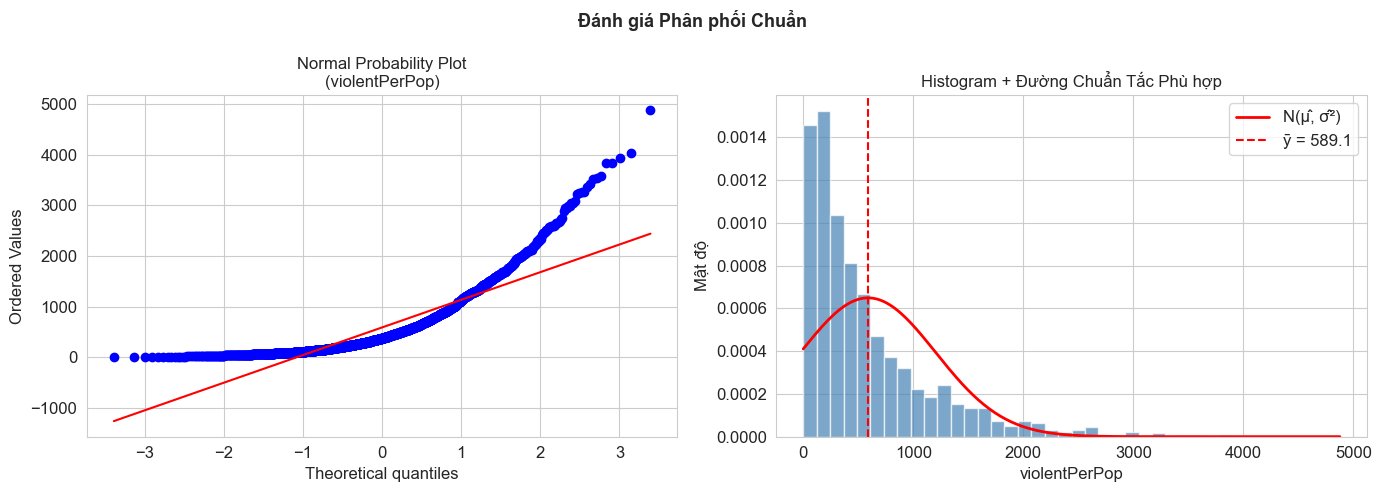

Biểu đồ kiểm tra phân phối chuẩn


In [23]:
# ── Phân tích Cỡ mẫu  ──
import math
from scipy.stats import norm, shapiro, t

target = 'violentPerPop'
y = df_clean[target].dropna()

print('=== KIỂM TRA ĐIỀU KIỆN CLT ===')
print(f'Cỡ mẫu hiện tại n = {len(y)}')
print(f'n >= 30? {"Có" if len(y) >= 30 else "Không"}')

# Thống kê phân phối mẫu
print('\n=== PHÂN PHỐI CỦA TRUNG BÌNH MẪU (Sampling Distribution of ȳ) ===')
mu_hat   = y.mean()
sigma_hat = y.std(ddof=1)   # s – ước lượng σ
n_current = len(y)
se       = sigma_hat / math.sqrt(n_current)   # σ_ȳ = s/√n
print(f'  Trung bình mẫu  ȳ      = {mu_hat:.2f}')
print(f'  Độ lệch chuẩn mẫu s   = {sigma_hat:.2f}')
print(f'  n = {n_current}')
print(f'  Sai số chuẩn của ȳ  SE = s/√n = {sigma_hat:.2f}/√{n_current} = {se:.4f}')
print(f'  → Theo CLT: ȳ ~ N({mu_hat:.1f}, {se:.4f}²)')


# Khoảng tin cậy 95% cho μ (dùng z vì n lớn)
z_95 = norm.ppf(0.975)
ci95 = (mu_hat - z_95*se, mu_hat + z_95*se)
print(f'\n  95% CI cho μ: ({ci95[0]:.2f}, {ci95[1]:.2f})')
print(f'  Bề rộng CI = {2*t_95*se:.2f}')

# Xác định cỡ mẫu cần thiết
print('\n=== XÁC ĐỊNH CỠ MẪU CẦN THIẾT ===')
E_values = [100, 75, 50, 25]   # sai số cho phép (vụ/100k dân)
alpha_vals = [0.05, 0.01]
print(f'  Ước lượng σ ≈ range/4 = ({y.max():.0f} - {y.min():.0f})/4 = {(y.max()-y.min())/4:.1f}')
sigma_est = (y.max() - y.min()) / 4
print(f'\n  Bảng cỡ mẫu cần thiết (n = (z·σ/E)²):')
print(f'  {"Sai số E":>12} | {"α=0.05 (z=1.96)":>18} | {"α=0.01 (z=2.576)":>18}')
print('  ' + '-'*56)
for E in E_values:
    n_05  = math.ceil((1.96  * sigma_est / E)**2)
    n_01  = math.ceil((2.576 * sigma_est / E)**2)
    print(f'  {E:>12} | {n_05:>18} | {n_01:>18}')

# Nhận xét: n hiện tại có đủ không?
E_target = 55
n_needed = math.ceil((1.96 * sigma_est / E_target)**2)
print(f'\n  ► Với E = {E_target}, α = 0.05: cần n ≥ {n_needed}')
print(f'Cỡ mẫu hiện tại n = {n_current} {"≥" if n_current >= n_needed else "<"} {n_needed}')
print(f'Kết luận: {"Cỡ mẫu đủ" if n_current >= n_needed else "Cỡ mẫu không đủ"} cho sai số E = {E_target}')

# Normal probability plot để kiểm tra phân phối chuẩn (Bài 4 – mục 7)
import matplotlib.pyplot as plt, scipy.stats as sps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot
sps.probplot(y, dist='norm', plot=axes[0])
axes[0].set_title('Normal Probability Plot\n(violentPerPop)', fontsize=12)

# Histogram + Normal overlay
import numpy as np
axes[1].hist(y, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')
xr = np.linspace(y.min(), y.max(), 200)
axes[1].plot(xr, sps.norm.pdf(xr, mu_hat, sigma_hat), 'r-', lw=2, label='N(μ̂, σ̂²)')
axes[1].axvline(mu_hat, color='red', ls='--', label=f'ȳ = {mu_hat:.1f}')
axes[1].set_title('Histogram + Đường Chuẩn Tắc Phù hợp', fontsize=12)
axes[1].set_xlabel('violentPerPop')
axes[1].set_ylabel('Mật độ')
axes[1].legend()

plt.suptitle('Đánh giá Phân phối Chuẩn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Biểu đồ kiểm tra phân phối chuẩn')



### Nhận xét:
Dữ liệu tỷ lệ tội phạm bạo lực (violentPerPop) không tuân theo phân phối chuẩn.
- Biểu đồ Normal Probability Plot (Q-Q Plot): Nếu dữ liệu chuẩn, các chấm xanh sẽ bám sát vào đường thẳng màu đỏ. Tuy nhiên, ở đây các chấm xanh lại cong vọt lên cực kỳ gắt ở góc trên bên phải, cho thấy dữ liệu bị lệch phải rất nặng.
- Biểu đồ Histogram: Cột tần số thực tế (màu xanh) hoàn toàn không khớp với đường cong hình chuông lý tưởng (màu đỏ). Dữ liệu dồn cục thành một đỉnh cao ở bên trái và kéo một cái đuôi rất dài về phía tay phải (do chứa các điểm nóng bạo lực cực đoan).


=== SO SÁNH THỐNG KÊ MÔ PHỎNG VÀ LÝ THUYẾT (n=50) ===
1. Trung bình của các trung bình mẫu: 588.89 (Kỳ vọng lý thuyết: 589.08)
2. Độ lệch chuẩn của trung bình mẫu:   87.44 (SE lý thuyết: 86.94)


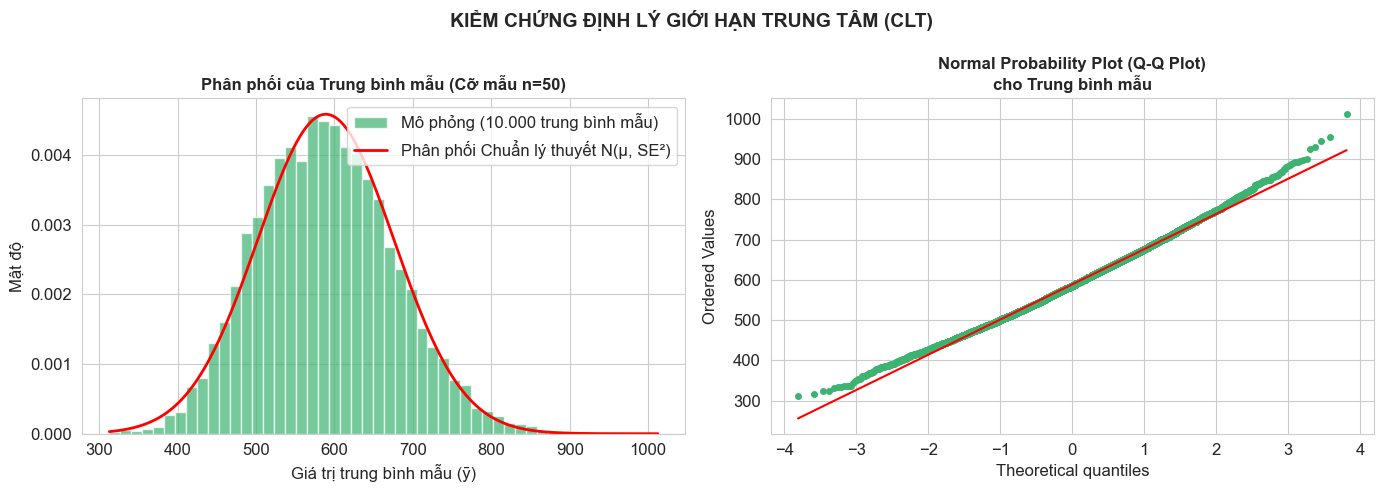

Biểu đồ kiểm chứng Định lý CLT thành công!


In [24]:
# ==========================================
# KIỂM CHỨNG ĐỊNH LÝ GIỚI HẠN TRUNG TÂM (CLT)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps

target = 'violentPerPop'
y = df_clean[target].dropna().values


np.random.seed(42)  # Khóa seed để kết quả chạy lần nào cũng giống nhau
num_simulations = 10000  # Số lần bốc mẫu lặp lại
sample_size = 50  # Cỡ của mỗi mẫu (n=50, đủ lớn theo CLT)

sample_means = []

# Lặp 10.000 lần: rút ngẫu nhiên n=50 quan sát từ y (có hoàn lại) và tính trung bình
for _ in range(num_simulations):
    sample = np.random.choice(y, size=sample_size, replace=True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

# --- THÔNG SỐ LÝ THUYẾT THEO CLT ---
mu_pop = y.mean()  # Kỳ vọng của tổng thể
sigma_pop = y.std(ddof=1)  # Độ lệch chuẩn của tổng thể
se_theory = sigma_pop / np.sqrt(sample_size)  # Sai số chuẩn lý thuyết (Standard Error)

print(f"=== SO SÁNH THỐNG KÊ MÔ PHỎNG VÀ LÝ THUYẾT (n={sample_size}) ===")
print(f"1. Trung bình của các trung bình mẫu: {sample_means.mean():.2f} (Kỳ vọng lý thuyết: {mu_pop:.2f})")
print(f"2. Độ lệch chuẩn của trung bình mẫu:   {sample_means.std(ddof=1):.2f} (SE lý thuyết: {se_theory:.2f})")

# --- VẼ BIỂU ĐỒ KIỂM CHỨNG ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Histogram của các trung bình mẫu + Đường Normal lý thuyết
axes[0].hist(sample_means, bins=50, density=True, color='mediumseagreen',
             alpha=0.7, edgecolor='white', label='Mô phỏng (10.000 trung bình mẫu)')

# Vẽ đường phân phối chuẩn lý thuyết
xr = np.linspace(sample_means.min(), sample_means.max(), 200)
axes[0].plot(xr, sps.norm.pdf(xr, mu_pop, se_theory), 'r-', lw=2,
             label='Phân phối Chuẩn lý thuyết N(μ, SE²)')
axes[0].set_title(f'Phân phối của Trung bình mẫu (Cỡ mẫu n={sample_size})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị trung bình mẫu (ȳ)')
axes[0].set_ylabel('Mật độ')
axes[0].legend()

# Biểu đồ 2: Q-Q Plot cho các trung bình mẫu
sps.probplot(sample_means, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor('mediumseagreen')
axes[1].get_lines()[0].set_markeredgecolor('mediumseagreen')
axes[1].get_lines()[0].set_markersize(4)
axes[1].set_title('Normal Probability Plot (Q-Q Plot)\ncho Trung bình mẫu', fontsize=12, fontweight='bold')

plt.suptitle('KIỂM CHỨNG ĐỊNH LÝ GIỚI HẠN TRUNG TÂM (CLT)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Biểu đồ kiểm chứng Định lý CLT thành công!')

### Kết luận & Ý nghĩa thống kê:
Mặc dù quần thể gốc không có phân phối chuẩn, nhưng do cỡ mẫu của bộ dữ liệu rất lớn (n=1994≫30), theo Định lý Giới hạn Trung tâm (CLT), phân phối của trung bình mẫu vẫn sẽ xấp xỉ phân phối chuẩn. Do đó, các phép tính toán Khoảng tin cậy (CI) và kiểm định giả thuyết ở các bước tiếp theo vẫn đảm bảo độ chính xác và hoàn toàn hợp lệ.

## 5. Kiểm định 2 Trung bình (Two-Sample T-test)

**Câu hỏi nghiên cứu:** Cộng đồng có thu nhập trung vị thấp có tỷ lệ tội phạm bạo lực cao hơn cộng đồng thu nhập cao không?

- $H_0$: $\mu_{\text{low income}} - \mu_{\text{high income}} \leq 0$ (thu nhập thấp không có tỷ lệ tội phạm cao hơn)
- $H_a$: $\mu_{\text{low income}} - \mu_{\text{high income}} > 0$ (thu nhập thấp có tỷ lệ tội phạm CAO HƠN)

In [25]:
# Phân nhóm theo thu nhập: dưới và trên trung vị
if 'medIncome' in df_clean.columns:
    income_median = df_clean['medIncome'].median()
    print(f'Thu nhập trung vị (median): ${income_median:,.0f}')
    
    group_low  = df_clean[df_clean['medIncome'] <= income_median]['violentPerPop'].dropna()
    group_high = df_clean[df_clean['medIncome'] > income_median]['violentPerPop'].dropna()
    
    print(f'\nNhóm Thu nhập THẤP (≤ ${income_median:,.0f}):')
    print(f'  n = {len(group_low)}')
    print(f'  Trung bình (ȳ₁) = {group_low.mean():.2f}')
    print(f'  Độ lệch chuẩn (s₁) = {group_low.std():.2f}')
    
    print(f'\nNhóm Thu nhập CAO (> ${income_median:,.0f}):')
    print(f'  n = {len(group_high)}')
    print(f'  Trung bình (ȳ₂) = {group_high.mean():.2f}')
    print(f'  Độ lệch chuẩn (s₂) = {group_high.std():.2f}')

Thu nhập trung vị (median): $30,896

Nhóm Thu nhập THẤP (≤ $30,896):
  n = 998
  Trung bình (ȳ₁) = 825.87
  Độ lệch chuẩn (s₁) = 713.39

Nhóm Thu nhập CAO (> $30,896):
  n = 996
  Trung bình (ȳ₂) = 351.82
  Độ lệch chuẩn (s₂) = 366.77


In [28]:
# Bước 1: Kiểm tra phương sai bằng F-test (Levene's test)
from scipy.stats import levene
stat_levene, p_levene = levene(group_low, group_high)
print('=== BƯỚC 1: KIỂM TRA ĐẲNG PHƯƠNG SAI (Levene Test) ===')
print(f'F-statistic = {stat_levene:.4f}')
print(f'p-value     = {p_levene:.4f}')
equal_var = p_levene > 0.05
print(f'Kết luận: Phương sai hai nhóm {"BẰNG NHAU" if equal_var else "KHÔNG BẰNG NHAU"} (α=0.05)')
print(f'→ Áp dụng: {"Trường hợp 1 (pooled)" if equal_var else "Trường hợp 2 (Welch)"}')

# Bước 2: T-test (một phía, kiểm định H_a: μ_low > μ_high)
alpha = 0.05
t_stat, p_two = ttest_ind(group_low, group_high, equal_var=equal_var)
p_one = p_two / 2  # Một phía

# Bậc tự do
n1, n2 = len(group_low), len(group_high)
if equal_var:
    df_t = n1 + n2 - 2
else:
    s1, s2 = group_low.std(), group_high.std()
    c = (s1**2/n1) / (s1**2/n1 + s2**2/n2)
    df_t = int((n1-1)*(n2-1) / ((1-c)**2*(n1-1) + c**2*(n2-1)))

t_critical = stats.t.ppf(1-alpha, df_t)  # Một phía

print('\n=== BƯỚC 2: KẾT QUẢ KIỂM ĐỊNH T-TEST ===')
print(f'Giả thuyết: H₀: μ₁ - μ₂ ≤ 0 | Hₐ: μ₁ - μ₂ > 0')
print(f'Mức ý nghĩa α = {alpha}')
print(f'Bậc tự do df = {df_t}')
print(f'Thống kê kiểm định t = {t_stat:.4f}')
print(f'Giá trị tới hạn t_crit = {t_critical:.4f}  [T.INV(1-{alpha},{df_t})]')
print(f'p-value (một phía) = {p_one:.6f}')
print()
if t_stat >= t_critical:
    print(f'KẾT LUẬN: t = {t_stat:.4f} ≥ t_crit = {t_critical:.4f}')
    print('   → BÁC BỎ H₀: Cộng đồng thu nhập thấp có tỷ lệ tội phạm cao hơn đáng kể.')
else:
    print(f'KẾT LUẬN: t = {t_stat:.4f} < t_crit = {t_critical:.4f}')
    print('   → Không bác bỏ H₀')
print(f'\n   Diễn giải p-value: p = {p_one:.6f} {"≤" if p_one <= alpha else ">"} α = {alpha}')

=== BƯỚC 1: KIỂM TRA ĐẲNG PHƯƠNG SAI (Levene Test) ===
F-statistic = 218.4849
p-value     = 0.0000
Kết luận: Phương sai hai nhóm KHÔNG BẰNG NHAU (α=0.05)
→ Áp dụng: Trường hợp 2 (Welch)

=== BƯỚC 2: KẾT QUẢ KIỂM ĐỊNH T-TEST ===
Giả thuyết: H₀: μ₁ - μ₂ ≤ 0 | Hₐ: μ₁ - μ₂ > 0
Mức ý nghĩa α = 0.05
Bậc tự do df = 1490
Thống kê kiểm định t = 18.6655
Giá trị tới hạn t_crit = 1.6459  [T.INV(1-0.05,1490)]
p-value (một phía) = 0.000000

KẾT LUẬN: t = 18.6655 ≥ t_crit = 1.6459
   → BÁC BỎ H₀: Cộng đồng thu nhập thấp có tỷ lệ tội phạm cao hơn đáng kể.

   Diễn giải p-value: p = 0.000000 ≤ α = 0.05


### Nhận xét:
Cộng đồng có thu nhập thấp có tỷ lệ tội phạm bạo lực cao hơn rõ rệt và đáng kể so với cộng đồng có thu nhập cao

=== KHOẢNG TIN CẬY 95% cho (μ_low - μ_high) ===
Chênh lệch trung bình: ȳ₁ - ȳ₂ = 474.05
Standard Error: SE = 25.40
t(0.025, df=1490) = 1.9616

95% CI: (424.23, 523.87)

→ Với độ tin cậy 95%, nhóm thu nhập thấp có tỷ lệ tội phạm
  cao hơn nhóm thu nhập cao từ 424 đến 524 vụ/100.000 dân.


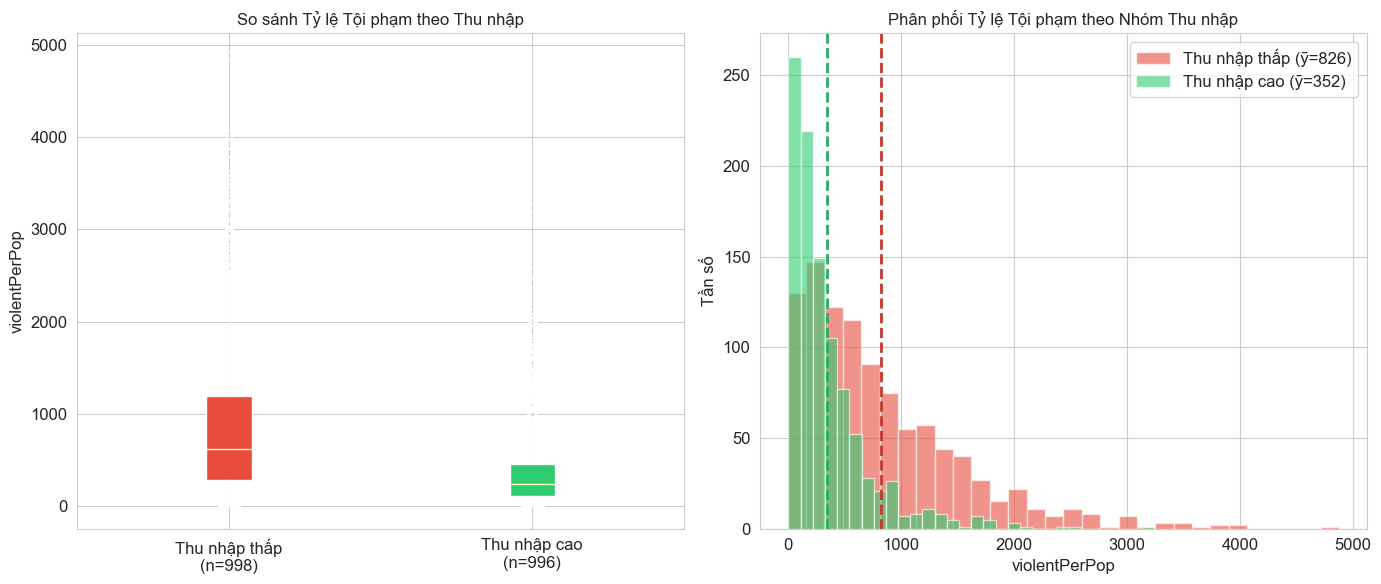

Biểu đồ 3: So sánh 2 nhóm thu nhập


In [32]:
# Khoảng tin cậy 95% cho μ₁ - μ₂
diff_mean = group_low.mean() - group_high.mean()
if equal_var:
    sp2 = ((n1-1)*group_low.var() + (n2-1)*group_high.var()) / (n1+n2-2)
    sp = np.sqrt(sp2)
    se = sp * np.sqrt(1/n1 + 1/n2)
else:
    se = np.sqrt(group_low.var()/n1 + group_high.var()/n2)

t_95 = stats.t.ppf(0.975, df_t)
ci_low  = diff_mean - t_95 * se
ci_high = diff_mean + t_95 * se

print('=== KHOẢNG TIN CẬY 95% cho (μ_low - μ_high) ===')
print(f'Chênh lệch trung bình: ȳ₁ - ȳ₂ = {diff_mean:.2f}')
print(f'Standard Error: SE = {se:.2f}')
print(f't(0.025, df={df_t}) = {t_95:.4f}')
print(f'\n95% CI: ({ci_low:.2f}, {ci_high:.2f})')
print(f'\n→ Với độ tin cậy 95%, nhóm thu nhập thấp có tỷ lệ tội phạm')
print(f'  cao hơn nhóm thu nhập cao từ {ci_low:.0f} đến {ci_high:.0f} vụ/100.000 dân.')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
data_plot = [group_low.values, group_high.values]
bp = axes[0].boxplot(data_plot, labels=['Thu nhập thấp\n(n={})'.format(n1),
                                          'Thu nhập cao\n(n={})'.format(n2)],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][1].set_facecolor('#2ecc71')
axes[0].set_title('So sánh Tỷ lệ Tội phạm theo Thu nhập', fontsize=12)
axes[0].set_ylabel('violentPerPop')

# Phân phối
axes[1].hist(group_low, bins=30, alpha=0.6, color='#e74c3c', label=f'Thu nhập thấp (ȳ={group_low.mean():.0f})')
axes[1].hist(group_high, bins=30, alpha=0.6, color='#2ecc71', label=f'Thu nhập cao (ȳ={group_high.mean():.0f})')
axes[1].axvline(group_low.mean(), color='#c0392b', linestyle='--', linewidth=2)
axes[1].axvline(group_high.mean(), color='#27ae60', linestyle='--', linewidth=2)
axes[1].set_title('Phân phối Tỷ lệ Tội phạm theo Nhóm Thu nhập', fontsize=12)
axes[1].set_xlabel('violentPerPop')
axes[1].set_ylabel('Tần số')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Biểu đồ 3: So sánh 2 nhóm thu nhập')

### Nhận xét:
1. Về sự chênh lệch (Boxplot bên trái):
Biểu đồ cho thấy sự khác biệt rõ rệt và đáng kể về tỷ lệ tội phạm giữa hai nhóm thu nhập. Nhóm cộng đồng có thu nhập thấp (màu đỏ) có mức độ tội phạm bạo lực trung bình cao hơn hẳn và phạm vi biến động dữ liệu rộng hơn so với nhóm thu nhập cao (màu xanh).
2. Về hình thái phân phối (Histogram bên phải):
Phân phối của nhóm thu nhập thấp (màu đỏ) bị lệch phải mạnh và trải dài, trong khi phân phối của nhóm thu nhập cao (màu xanh) tập trung rất chặt chẽ tại vùng có tỷ lệ tội phạm thấp. Sự tách biệt giữa hai đỉnh trung bình (đường nét đứt) cho thấy thu nhập là một yếu tố dự báo mạnh mẽ và trực tiếp đối với tỷ lệ tội phạm bạo lực của cộng đồng.

=> Kết luận: Với khoảng tin cậy 95% khẳng định nhóm thu nhập thấp có số vụ tội phạm cao hơn đáng kể (từ 424 đến 524 vụ/100k dân so với nhóm thu nhập cao), kết quả này là bằng chứng thống kê vững chắc cho thấy sự bất bình đẳng kinh tế có tác động tiêu cực đến an ninh xã hội.

## 6. Phân tích Phương sai Một yếu tố (One-Way ANOVA)

**Câu hỏi nghiên cứu:** Tỷ lệ tội phạm bạo lực có khác nhau có ý nghĩa thống kê
giữa các vùng có mức độ cấu trúc gia đình khác nhau (Tỷ lệ gia đình đủ cha mẹ: Thấp / Trung bình / Cao)?

- $H_0$: $\mu_1 = \mu_2 = \mu_3$ (Trung bình tỷ lệ tội phạm ba nhóm bằng nhau)
- $H_a$: Tồn tại ít nhất hai nhóm có trung bình khác nhau

**Điều kiện áp dụng ANOVA:**
1. Các mẫu độc lập
2. Phân phối của mỗi nhóm xấp xỉ chuẩn
3. Phương sai đồng nhất giữa các nhóm (Homogeneity of Variance)


In [39]:
# ── Chuẩn bị dữ liệu cho ANOVA ──
if 'pctKids2Par' in df_clean.columns:
    df_clean['family_cat'] = pd.cut(
        df_clean['pctKids2Par'],
        bins=[0, 50, 75, 100],
        labels=['Thấp (<50%)', 'Trung bình (50-75%)', 'Cao (>75%)']
    )
    
    # Lấy dữ liệu 3 nhóm
    groups = [
        df_clean[df_clean['family_cat'] == 'Thấp (<50%)']['violentPerPop'].dropna().values,
        df_clean[df_clean['family_cat'] == 'Trung bình (50-75%)']['violentPerPop'].dropna().values,
        df_clean[df_clean['family_cat'] == 'Cao (>75%)']['violentPerPop'].dropna().values
    ]
    
    print('Số lượng mẫu mỗi nhóm cấu trúc gia đình:')
    print(df_clean['family_cat'].value_counts().sort_index())


Số lượng mẫu mỗi nhóm cấu trúc gia đình:
family_cat
Thấp (<50%)             128
Trung bình (50-75%)    1059
Cao (>75%)              807
Name: count, dtype: int64


In [42]:
# ── Tính ANOVA thủ công và bằng scipy ──
import numpy as np
from scipy.stats import f as f_dist, f_oneway

# Tính SSB, SSW, SST thủ công (theo công thức Bài 7)
k = len(groups)
N = sum(len(g) for g in groups)
grand_mean_val = np.concatenate(groups).mean()

SSB = sum(len(g) * (g.mean() - grand_mean_val)**2 for g in groups)
SSW = sum(((g - g.mean())**2).sum() for g in groups)
SST = SSB + SSW

df_between = k - 1
df_within  = N - k
df_total   = N - 1

MSB = SSB / df_between
MSW = SSW / df_within
F_stat = MSB / MSW

alpha_anova = 0.05
F_critical  = f_dist.ppf(1 - alpha_anova, df_between, df_within)
p_anova     = f_dist.sf(F_stat, df_between, df_within)

print('=== BẢNG PHÂN TÍCH PHƯƠNG SAI (ANOVA) ===')
print(f'  {"Nguồn biến thiên":<25} {"SS":>12} {"df":>6} {"MS":>12} {"F":>10}')
print('  ' + '-'*68)
print(f'  {"Giữa các nhóm (SSB)":<25} {SSB:>12.2f} {df_between:>6} {MSB:>12.4f} {F_stat:>10.4f}')
print(f'  {"Trong nội bộ nhóm (SSW)":<25} {SSW:>12.2f} {df_within:>6} {MSW:>12.4f}')
print(f'  {"Tổng cộng (SST)":<25} {SST:>12.2f} {df_total:>6}')
print()
print(f'  Mức ý nghĩa α = {alpha_anova}')
print(f'  F_critical = F({df_between}, {df_within}, α={alpha_anova}) = {F_critical:.4f}')
print(f'  F_test     = {F_stat:.4f}')
print(f'  p-value    = {p_anova:.6f}')
print()

if F_stat > F_critical:
    print(f'KẾT LUẬN: F = {F_stat:.4f} > F_crit = {F_critical:.4f}')
    print(f'     → Bác bỏ H₀: Có sự khác biệt có ý nghĩa thống kê về')
    print(f'       tỷ lệ tội phạm giữa các mức độ cấu trúc gia đình khác nhau (α={alpha_anova}).')
else:
    print(f'KẾT LUẬN: F = {F_stat:.4f} ≤ F_crit = {F_critical:.4f}')
    print(f'     → Không bác bỏ H₀')

print(f'  p-value = {p_anova:.6f} {"≤" if p_anova <= alpha_anova else ">"} α = {alpha_anova}')

# Xác minh bằng scipy
F_scipy, p_scipy = f_oneway(*groups)
print(f'\n  Xác minh với scipy.stats.f_oneway: F = {F_scipy:.4f}, p = {p_scipy:.6f}')


=== BẢNG PHÂN TÍCH PHƯƠNG SAI (ANOVA) ===
  Nguồn biến thiên                    SS     df           MS          F
  --------------------------------------------------------------------
  Giữa các nhóm (SSB)       323544564.46      2 161772282.2304   749.5144
  Trong nội bộ nhóm (SSW)   429729723.26   1991  215836.1242
  Tổng cộng (SST)           753274287.72   1993

  Mức ý nghĩa α = 0.05
  F_critical = F(2, 1991, α=0.05) = 3.0002
  F_test     = 749.5144
  p-value    = 0.000000

KẾT LUẬN: F = 749.5144 > F_crit = 3.0002
     → Bác bỏ H₀: Có sự khác biệt có ý nghĩa thống kê về
       tỷ lệ tội phạm giữa các mức độ cấu trúc gia đình khác nhau (α=0.05).
  p-value = 0.000000 ≤ α = 0.05

  Xác minh với scipy.stats.f_oneway: F = 749.5144, p = 0.000000


=== SO SÁNH CẶP ĐÔI (POST-HOC – Tukey-inspired) ===
  MSW = 215836.1242,  df_within = 1991
  So sánh                                    Chênh lệch ȳ         SE        t Kết luận
  ------------------------------------------------------------------------------------------
  Thấp (<50%) vs Trung bình (                     1081.24      43.47   24.871  Khác biệt
  Thấp (<50%) vs Cao (>75%)                       1593.60      44.20   36.054  Khác biệt
  Trung bình ( vs Cao (>75%)                       512.36      21.71   23.602  Khác biệt


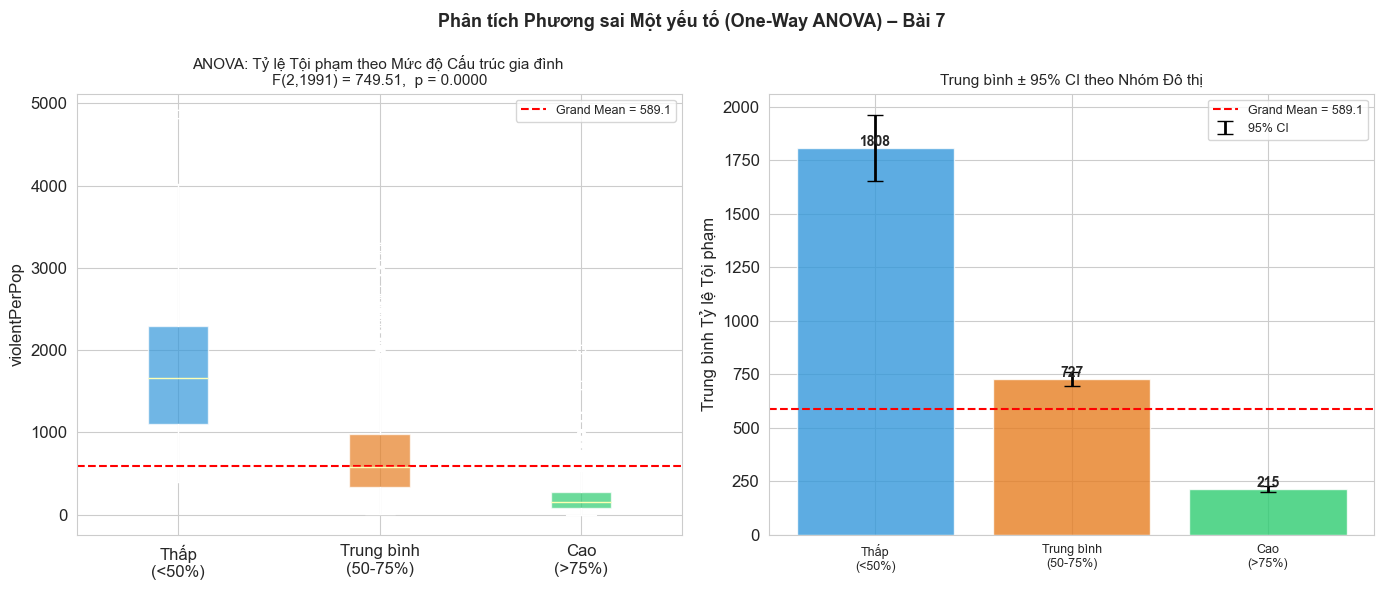

Biểu đồ ANOVA


In [46]:
# ── Post-hoc: Tukey HSD (so sánh cặp đôi sau khi bác bỏ H₀) ──
group_labels = ['Thấp (<50%)', 'Trung bình (50-75%)', 'Cao (>75%)']

from itertools import combinations

print('=== SO SÁNH CẶP ĐÔI (POST-HOC – Tukey-inspired) ===')
print(f'  MSW = {MSW:.4f},  df_within = {df_within}')
from scipy.stats import t as t_dist
t_crit_posthoc = t_dist.ppf(1 - 0.025, df_within)  # two-sided α=0.05

print(f'  {"So sánh":<40} {"Chênh lệch ȳ":>14} {"SE":>10} {"t":>8} {"Kết luận"}')
print('  ' + '-'*90)
for (i, g1), (j, g2) in combinations(enumerate(zip(group_labels, groups)), 2):
    lbl1, arr1 = g1
    lbl2, arr2 = g2
    diff = arr1.mean() - arr2.mean()
    se_pair = np.sqrt(MSW * (1/len(arr1) + 1/len(arr2)))
    t_pair  = abs(diff) / se_pair
    sig = 'Khác biệt' if t_pair > t_crit_posthoc else 'Không khác biệt'
    label_pair = f'{lbl1[:12]} vs {lbl2[:12]}'
    print(f'  {label_pair:<40} {diff:>14.2f} {se_pair:>10.2f} {t_pair:>8.3f}  {sig}')

# Visualize ANOVA
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot theo nhóm
colors_anova = ['#3498db', '#e67e22', '#2ecc71']
bp = axes[0].boxplot(groups, labels=[l.replace(' (', '\n(') for l in group_labels],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], colors_anova):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title(f'ANOVA: Tỷ lệ Tội phạm theo Mức độ Cấu trúc gia đình \n'
                  f'F({df_between},{df_within}) = {F_stat:.2f},  p = {p_anova:.4f}', fontsize=11)
axes[0].set_ylabel('violentPerPop')
axes[0].axhline(grand_mean_val, color='red', ls='--', lw=1.5, label=f'Grand Mean = {grand_mean_val:.1f}')
axes[0].legend(fontsize=9)

# Bar chart trung bình ± 1 SE
means = [g.mean() for g in groups]
sems  = [g.std()/np.sqrt(len(g)) for g in groups]
bars_a = axes[1].bar(range(k), means, color=colors_anova, alpha=0.8, edgecolor='white')
axes[1].errorbar(range(k), means, yerr=[1.96*s for s in sems],
                 fmt='none', color='black', capsize=6, lw=2, label='95% CI')
axes[1].set_xticks(range(k))
axes[1].set_xticklabels([l.replace(' (', '\n(') for l in group_labels], fontsize=9)
axes[1].set_ylabel('Trung bình Tỷ lệ Tội phạm')
axes[1].set_title('Trung bình ± 95% CI theo Nhóm Đô thị', fontsize=11)
axes[1].axhline(grand_mean_val, color='red', ls='--', lw=1.5, label=f'Grand Mean = {grand_mean_val:.1f}')
for bar, m in zip(bars_a, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{m:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Phân tích Phương sai Một yếu tố (One-Way ANOVA) – Bài 7',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.show()
print('Biểu đồ ANOVA')


### Nhận xét:
1. Boxplot (bên trái):
- Nhóm "Thấp (<50%)": Có tỷ lệ tội phạm bạo lực cao nhất với mức trung bình ≈ 875 (vụ/100K dân). Phân phối có độ trải rộng lớn, xuất hiện nhiều điểm ngoại lai (outliers), cho thấy sự bất bình đẳng cao trong nhóm này.
- Nhóm "Trung bình (50-75%)": Tỷ lệ tội phạm ở mức trung bình, khoảng 400-500 (vụ/100K dân). Phân phối tương đối tập trung hơn so với nhóm thấp.
- Nhóm "Cao (>75%)": Có tỷ lệ tội phạm thấp nhất, trung bình chỉ khoảng 200 (vụ/100K dân). Dữ liệu tập trung ở vùng giá trị thấp, ít điểm ngoại lai.
2. Biểu đồ cột với 95% CI (bên phải):

- Giá trị trung bình của 3 nhóm khác biệt rõ rệt: ≈ 875, ≈ 400, ≈ 200.
- Khoảng tin cậy 95% của các nhóm không giao nhau, khẳng định sự khác biệt có ý nghĩa thống kê giữa cả 3 nhóm.
- Đường Grand Mean = 589.1 được đánh dấu bằng đường đứt nét đỏ, nằm giữa mức trung bình của nhóm "Thấp" và "Trung bình", phản ánh giá trị trung bình chung của toàn bộ dữ liệu.

### Kết luận:
Với F(2, 1991) = 749.51 và p-value = 0.0000 < 0.05:

- Có sự khác biệt có ý nghĩa thống kê về tỷ lệ tội phạm bạo lực giữa các nhóm cộng đồng có mức độ cấu trúc gia đình khác nhau.
- Mối quan hệ có xu hướng rõ ràng: Cấu trúc gia đình càng vững chắc (tỷ lệ trẻ em sống với cả cha và mẹ càng cao) thì tỷ lệ tội phạm bạo lực càng thấp.

## 6. Kiểm định Chi-bình phương (Chi-Square Test) – Bài 9

**Câu hỏi nghiên cứu:** Mức độ cấu trúc gia đình, thu nhập trung vị và mức độ tội phạm có mối liên hệ với nhau không?

- $H_0$: Mức cấu trúc gia đình (hoặc thu nhập) và mức tội phạm là **độc lập** với nhau
- $H_a$: Mức cấu trúc gia đình (hoặc thu nhập) và mức tội phạm **có liên hệ**


In [47]:
# Phân loại biến thành các nhóm (biến phân loại)
if 'pctKids2Par' in df_clean.columns and 'medIncome' in df_clean.columns:
    df_clean['crime_level'] = pd.cut(
        df_clean['violentPerPop'],
        bins=[0, 200, 600, float('inf')],
        labels=['Thấp', 'Trung bình', 'Cao']
    )
    
    # Cấu trúc gia đình
    df_clean['family_cat'] = pd.cut(
        df_clean['pctKids2Par'],
        bins=[0, 50, 75, 100],
        labels=['Thấp (<50%)', 'Trung bình (50-75%)', 'Cao (>75%)']
    )
    
    # Thu nhập
    df_clean['income_cat'] = pd.cut(
        df_clean['medIncome'],
        bins=[0, 30000, 60000, float('inf')],
        labels=['Thấp (<30k)', 'Trung bình (30k-60k)', 'Cao (>60k)']
    )

    # Lập bảng tần số phối hợp cho Cấu trúc gia đình và Tội phạm
    ct_family = pd.crosstab(df_clean['family_cat'], df_clean['crime_level'])
    print('=== BẢNG TẦN SỐ QUAN SÁT (Cấu trúc gia đình & Tội phạm) ===')
    print(ct_family)
    
    # Lập bảng tần số phối hợp cho Thu nhập và Tội phạm
    ct_income = pd.crosstab(df_clean['income_cat'], df_clean['crime_level'])
    print('\n=== BẢNG TẦN SỐ QUAN SÁT (Thu nhập & Tội phạm) ===')
    print(ct_income)


=== BẢNG TẦN SỐ QUAN SÁT (Cấu trúc gia đình & Tội phạm) ===
crime_level          Thấp  Trung bình  Cao
family_cat                                
Thấp (<50%)             0           8  120
Trung bình (50-75%)   110         439  510
Cao (>75%)            481         285   40

=== BẢNG TẦN SỐ QUAN SÁT (Thu nhập & Tội phạm) ===
crime_level           Thấp  Trung bình  Cao
income_cat                                 
Thấp (<30k)            154         310  491
Trung bình (30k-60k)   359         411  177
Cao (>60k)              78          11    2


In [69]:
# Tính tần số kỳ vọng và thực hiện Chi-square test cho Cấu trúc gia đình
chi2_fam, p_chi_fam, dof_fam, expected_fam = chi2_contingency(ct_family)

print('=== KẾT QUẢ KIỂM ĐỊNH (Cấu trúc gia đình) ===')
print(f"Chi-Square Stat: {chi2_fam:.2f}")
print(f"P-value:         {p_chi_fam:.4e}")
print(f"Bậc tự do (df):  {dof_fam}")
if p_chi_fam < 0.05:
    print("=> Bác bỏ H0: Cấu trúc gia đình và mức độ tội phạm CÓ LIÊN HỆ với nhau.")
else:
    print("=> Chấp nhận H0: Không đủ bằng chứng cho thấy có sự liên hệ.")

# Chi-square test cho Thu nhập
chi2_inc, p_chi_inc, dof_inc, expected_inc = chi2_contingency(ct_income)

print('\n=== KẾT QUẢ KIỂM ĐỊNH (Thu nhập) ===')
print(f"Chi-Square Stat: {chi2_inc:.2f}")
print(f"P-value:         {p_chi_inc:.4e}")
if p_chi_inc < 0.05:
    print("=> Bác bỏ H0: Thu nhập và mức độ tội phạm CÓ LIÊN HỆ với nhau.")


=== KẾT QUẢ KIỂM ĐỊNH (Cấu trúc gia đình) ===
Chi-Square Stat: 855.90
P-value:         5.9723e-184
Bậc tự do (df):  4
=> Bác bỏ H0: Cấu trúc gia đình và mức độ tội phạm CÓ LIÊN HỆ với nhau.

=== KẾT QUẢ KIỂM ĐỊNH (Thu nhập) ===
Chi-Square Stat: 387.86
P-value:         1.1681e-82
=> Bác bỏ H0: Thu nhập và mức độ tội phạm CÓ LIÊN HỆ với nhau.


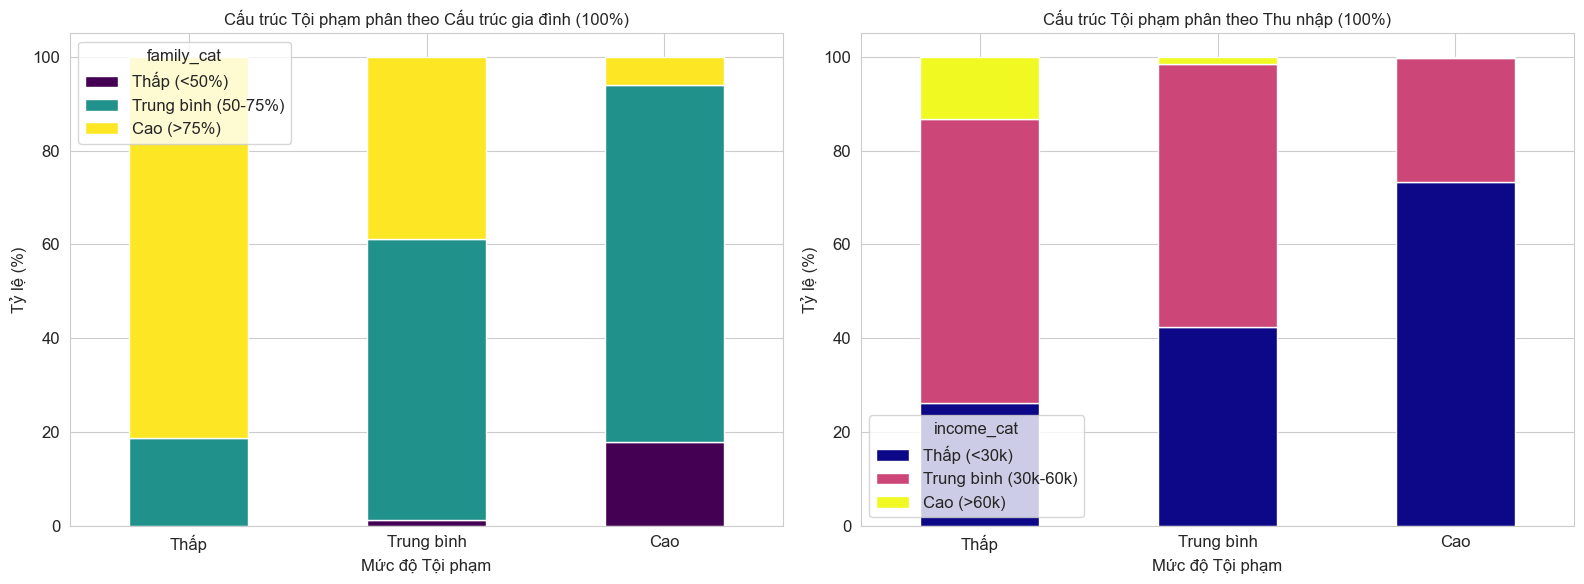

In [77]:
# Stacked bar chart thể hiện tỷ lệ
ct_pct_fam = ct_family.div(ct_family.sum(axis=0), axis=1) * 100
ct_pct_inc = ct_income.div(ct_income.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ct_pct_fam.T.plot(kind='bar', stacked=True, ax=axes[0], 
               colormap='viridis', edgecolor='white')
axes[0].set_title('Cấu trúc Tội phạm phân theo Cấu trúc gia đình (100%)', fontsize=12)
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].set_xlabel('Mức độ Tội phạm')
axes[0].tick_params(axis='x', rotation=0)

ct_pct_inc.T.plot(kind='bar', stacked=True, ax=axes[1], 
               colormap='plasma', edgecolor='white')
axes[1].set_title('Cấu trúc Tội phạm phân theo Thu nhập (100%)', fontsize=12)
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_xlabel('Mức độ Tội phạm')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 7. Hồi quy Tuyến tính (Linear Regression)

### 7.1. Hồi quy đơn biến: Thu nhập → Tỷ lệ Tội phạm

In [53]:
# Hồi quy đơn biến: medIncome → ViolentCrimesPerPop
if 'medIncome' in df_clean.columns:
    X_simple = df_clean['medIncome'].dropna()
    Y_simple = df_clean.loc[X_simple.index, 'violentPerPop'].dropna()
    X_simple = X_simple.loc[Y_simple.index]
    
    # Tính Sxy và Sxx thủ công (theo công thức trong bài)
    x_bar = X_simple.mean()
    y_bar = Y_simple.mean()
    Sxy = ((X_simple - x_bar) * (Y_simple - y_bar)).sum()
    Sxx = ((X_simple - x_bar)**2).sum()
    
    b1_manual = Sxy / Sxx
    b0_manual = y_bar - b1_manual * x_bar
    
    print('=== HỒI QUY ĐƠN BIẾN: medIncome → violentPerPop ===')
    print(f'\nTính thủ công (theo công thức bài 8):')
    print(f'  x̄ = {x_bar:,.2f}')
    print(f'  ȳ = {y_bar:.2f}')
    print(f'  Sxy = {Sxy:,.2f}')
    print(f'  Sxx = {Sxx:,.2f}')
    print(f'  β̂₁ = Sxy/Sxx = {b1_manual:.6f}')
    print(f'  β̂₀ = ȳ - β̂₁·x̄ = {b0_manual:.4f}')
    print(f'\n  → Phương trình hồi quy: Ŷ = {b0_manual:.2f} + ({b1_manual:.6f}) × medIncome')
    
    # Dùng statsmodels để lấy đầy đủ bảng phân tích
    X_sm = sm.add_constant(X_simple)
    model_simple = sm.OLS(Y_simple, X_sm).fit()
    print('\n=== BẢNG PHÂN TÍCH HỒI QUY (OLS) ===')
    print(model_simple.summary())

=== HỒI QUY ĐƠN BIẾN: medIncome → ViolentCrimesPerPop ===

Tính thủ công (theo công thức bài 8):
  x̄ = 33,699.33
  ȳ = 589.08
  Sxy = -6,520,836,045.91
  Sxx = 357,422,103,237.15
  β̂₁ = Sxy/Sxx = -0.018244
  β̂₀ = ȳ - β̂₁·x̄ = 1203.8920

  → Phương trình hồi quy: Ŷ = 1203.89 + (-0.018244) × medIncome

=== BẢNG PHÂN TÍCH HỒI QUY (OLS) ===
                            OLS Regression Results                            
Dep. Variable:          violentPerPop   R-squared:                       0.158
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     373.6
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.98e-76
Time:                        13:24:10   Log-Likelihood:                -15461.
No. Observations:                1994   AIC:                         3.093e+04
Df Residuals:                    1992   BIC:                         3.094e+04
Df Model:                 

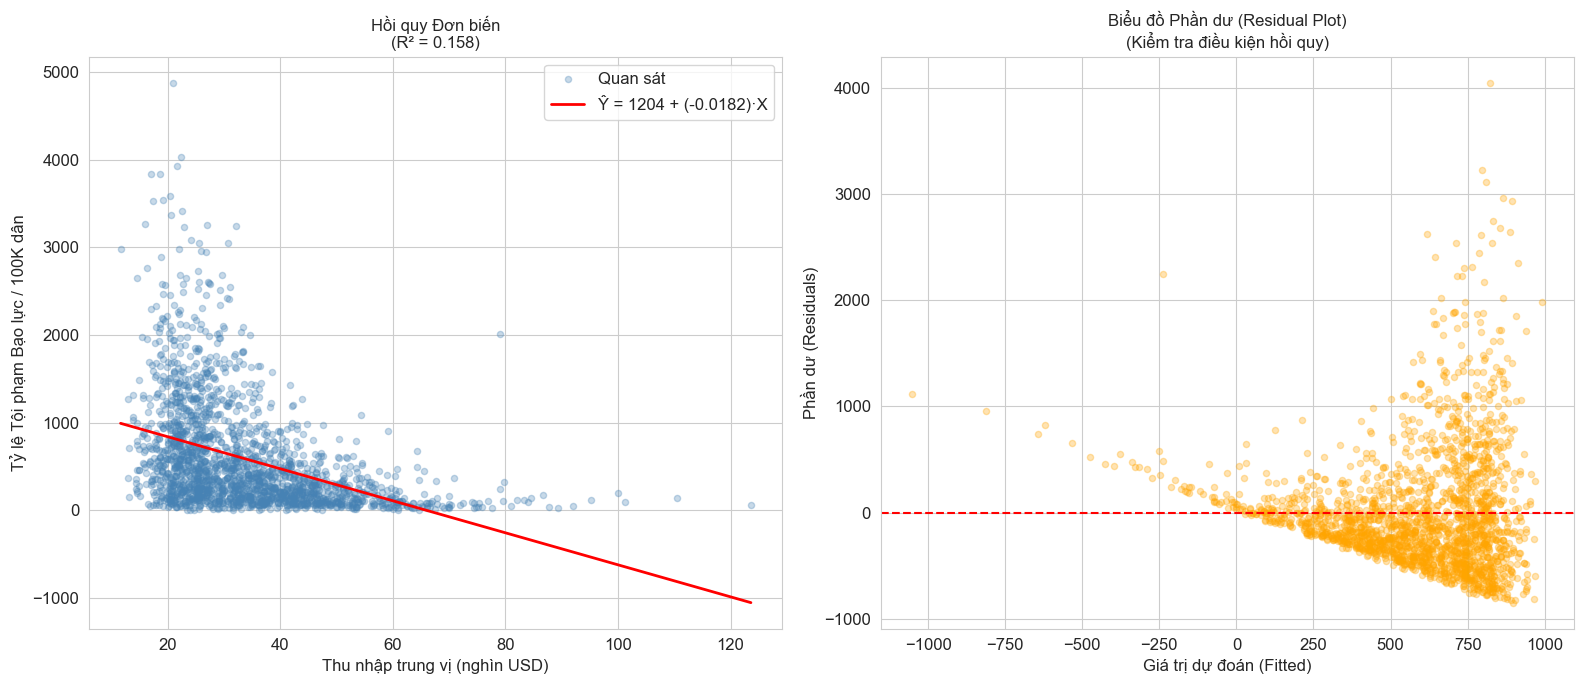

Biểu đồ 6: Hồi quy đơn biến
   R² = 0.1579 → Mô hình giải thích 15.8% biến động của Y


In [55]:
# Scatter plot + đường hồi quy
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter plot hồi quy
axes[0].scatter(X_simple/1000, Y_simple, alpha=0.3, s=20, color='steelblue', label='Quan sát')
x_line = np.linspace(X_simple.min(), X_simple.max(), 100)
y_line = b0_manual + b1_manual * x_line
axes[0].plot(x_line/1000, y_line, 'r-', linewidth=2, 
             label=f'Ŷ = {b0_manual:.0f} + ({b1_manual:.4f})·X')
axes[0].set_xlabel('Thu nhập trung vị (nghìn USD)')
axes[0].set_ylabel('Tỷ lệ Tội phạm Bạo lực / 100K dân')
axes[0].set_title(f'Hồi quy Đơn biến\n(R² = {model_simple.rsquared:.3f})', fontsize=12)
axes[0].legend()

# Residual plot
residuals = model_simple.resid
fitted = model_simple.fittedvalues
axes[1].scatter(fitted, residuals, alpha=0.3, s=20, color='orange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Giá trị dự đoán (Fitted)')
axes[1].set_ylabel('Phần dư (Residuals)')
axes[1].set_title('Biểu đồ Phần dư (Residual Plot)\n(Kiểm tra điều kiện hồi quy)', fontsize=12)

plt.tight_layout()
plt.show()
print(f'Biểu đồ 6: Hồi quy đơn biến')
print(f'   R² = {model_simple.rsquared:.4f} → Mô hình giải thích {model_simple.rsquared*100:.1f}% biến động của Y')

### 7.2. Hồi quy Đa biến (Multiple Linear Regression)


In [60]:
# Chọn các biến độc lập cho hồi quy đa biến
predictors_try = ['pct12-29', 'pctCollGrad',
            'pctPoverty', 'medIncome', 'pctKidsBornNevrMarr', 'pctKids2Par']


predictors = [p for p in predictors_try if p in df_clean.columns]

# Drop missing
df_reg = df_clean[predictors + ['violentPerPop']].dropna()

X_multi = df_reg[predictors]
Y_multi = df_reg['violentPerPop']

# Thêm hằng số intercept
X_multi_sm = sm.add_constant(X_multi)

# Xây dựng mô hình
model_multi = sm.OLS(Y_multi, X_multi_sm).fit()

print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:          violentPerPop   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     471.6
Date:                Wed, 17 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:28:01   Log-Likelihood:                -14750.
No. Observations:                1994   AIC:                         2.951e+04
Df Residuals:                    1987   BIC:                         2.955e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                1950.4723    

In [61]:
# So sánh hệ số chuẩn hoá (Standardized Coefficients)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)
X_scaled_sm = sm.add_constant(X_scaled)
model_std = sm.OLS(Y_multi, X_scaled_sm).fit()

# Tầm quan trọng các biến (theo hệ số chuẩn hoá)
coef_df = pd.DataFrame({
    'Biến': predictors,
    'Hệ số (β)': model_multi.params[1:].values.round(4),
    'Hệ số chuẩn hoá': model_std.params[1:].values.round(4),
    'p-value': model_multi.pvalues[1:].values.round(4),
    'Ý nghĩa (α=0.05)': ['Có ý nghĩa' if p < 0.05 else 'Không ý nghĩa'
                          for p in model_multi.pvalues[1:]]
})
coef_df = coef_df.sort_values('Hệ số chuẩn hoá', key=abs, ascending=False)
print('=== TẦM QUAN TRỌNG CÁC BIẾN (Standardized Coefficients) ===')
print(coef_df.to_string(index=False))

print(f'\nR² = {model_multi.rsquared:.4f} → Mô hình giải thích {model_multi.rsquared*100:.1f}% biến động')
print(f'R² điều chỉnh = {model_multi.rsquared_adj:.4f}')
print(f'F-statistic = {model_multi.fvalue:.2f}, p-value = {model_multi.f_pvalue:.2e}')

=== TẦM QUAN TRỌNG CÁC BIẾN (Standardized Coefficients) ===
               Biến  Hệ số (β)  Hệ số chuẩn hoá  p-value Ý nghĩa (α=0.05)
        pctKids2Par   -23.1259        -273.8771   0.0000       Có ý nghĩa
pctKidsBornNevrMarr    78.1443         240.1577   0.0000       Có ý nghĩa
          medIncome     0.0059          79.1750   0.0001       Có ý nghĩa
           pct12-29    -6.2183         -38.2209   0.0007       Có ý nghĩa
         pctPoverty     3.3470          28.4740   0.0986    Không ý nghĩa
        pctCollGrad    -1.4804         -18.5214   0.1723    Không ý nghĩa

R² = 0.5875 → Mô hình giải thích 58.7% biến động
R² điều chỉnh = 0.5862
F-statistic = 471.64, p-value = 0.00e+00


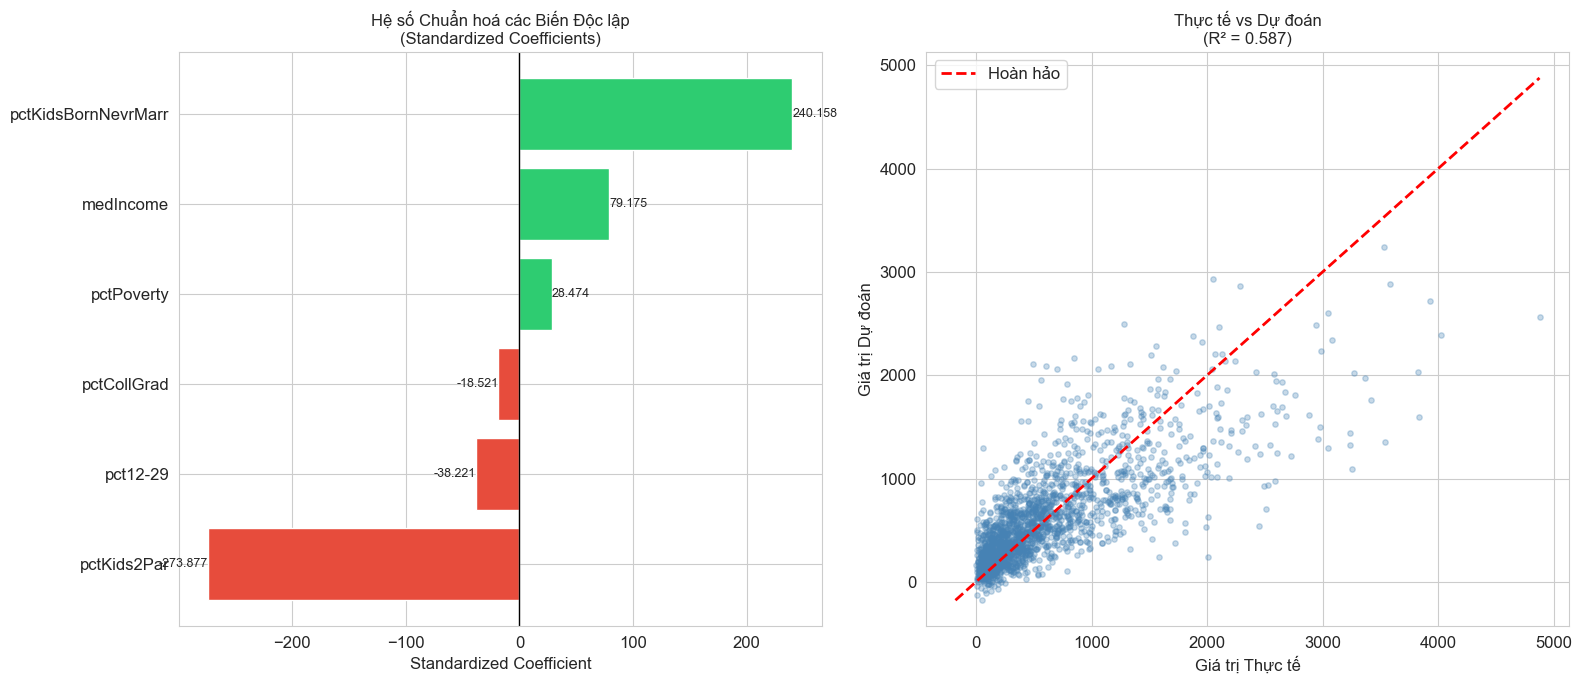

Biểu đồ 7: Hồi quy đa biến


In [63]:
# Visualize: Coefficient plot + Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Coefficient plot
coef_sorted = coef_df.sort_values('Hệ số chuẩn hoá')
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_sorted['Hệ số chuẩn hoá']]
bars = axes[0].barh(coef_sorted['Biến'], coef_sorted['Hệ số chuẩn hoá'], color=colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Hệ số Chuẩn hoá các Biến Độc lập\n(Standardized Coefficients)', fontsize=12)
axes[0].set_xlabel('Standardized Coefficient')
for bar, val in zip(bars, coef_sorted['Hệ số chuẩn hoá']):
    axes[0].text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Actual vs Predicted
y_pred = model_multi.fittedvalues
axes[1].scatter(Y_multi, y_pred, alpha=0.3, s=15, color='steelblue')
min_val, max_val = min(Y_multi.min(), y_pred.min()), max(Y_multi.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Hoàn hảo')
axes[1].set_xlabel('Giá trị Thực tế')
axes[1].set_ylabel('Giá trị Dự đoán')
axes[1].set_title(f'Thực tế vs Dự đoán\n(R² = {model_multi.rsquared:.3f})', fontsize=12)
axes[1].legend()

plt.tight_layout()

plt.show()
print('Biểu đồ 7: Hồi quy đa biến')

## 8. Ma trận Tương quan (Correlation Matrix)

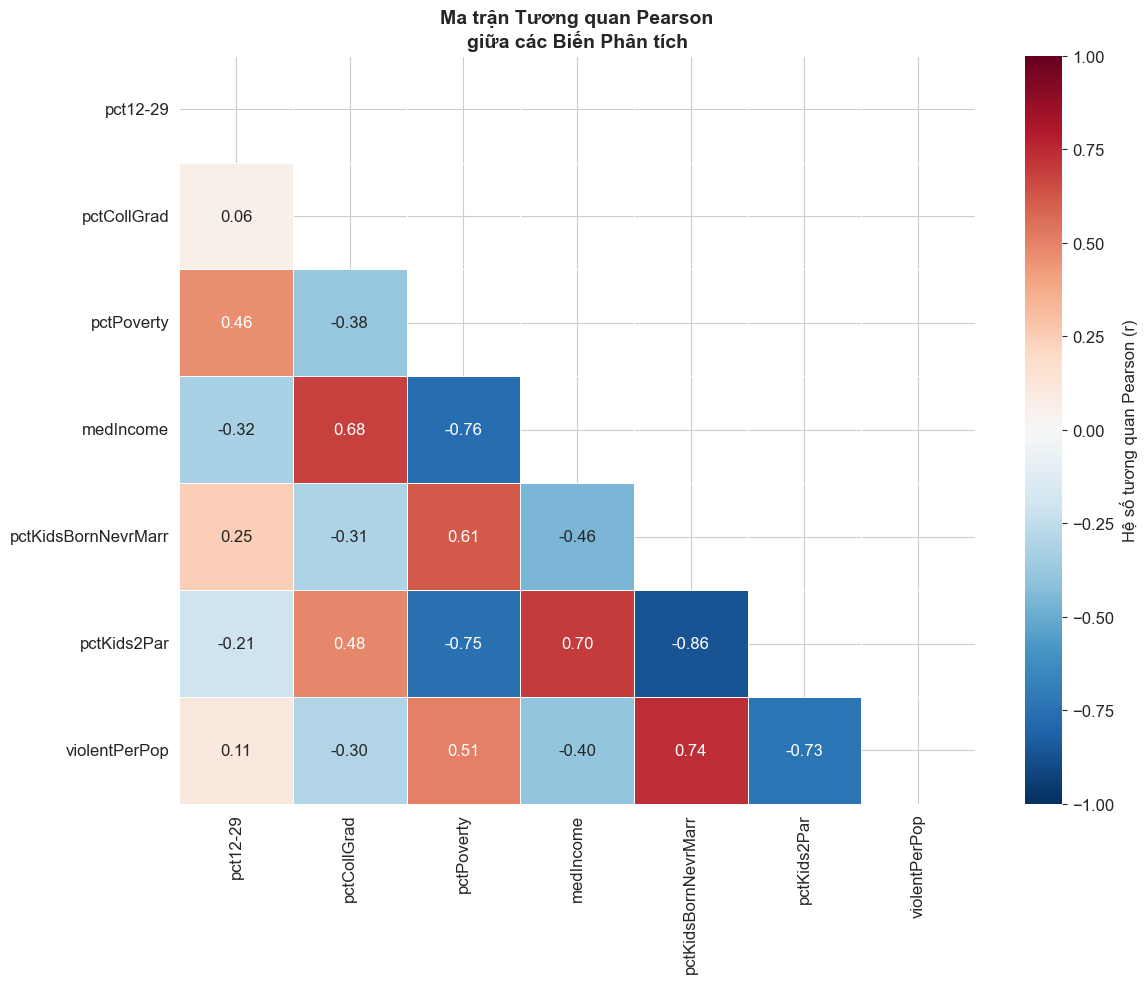

=== TƯƠNG QUAN VỚI violentPerPop ===
  pctKidsBornNevrMarr      : r = +0.7381 ↑
  pctKids2Par              : r = -0.7281 ↓
  pctPoverty               : r = +0.5053 ↑
  medIncome                : r = -0.3974 ↓
  pctCollGrad              : r = -0.2999 ↓
  pct12-29                 : r = +0.1059 ↑


In [65]:
# Ma trận tương quan Pearson
corr_vars = predictors + ['violentPerPop']
corr_matrix = df_clean[corr_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, 
            cbar_kws={'label': 'Hệ số tương quan Pearson (r)'},
            vmin=-1, vmax=1)
ax.set_title('Ma trận Tương quan Pearson\ngiữa các Biến Phân tích', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

# In tương quan với ViolentCrimesPerPop
print('=== TƯƠNG QUAN VỚI violentPerPop ===')
corr_target = corr_matrix['violentPerPop'].drop('violentPerPop').sort_values(key=abs, ascending=False)
for var, r in corr_target.items():
    direction = '↑' if r > 0 else '↓'
    print(f'  {var:25s}: r = {r:+.4f} {direction}')

## 9. Tổng hợp Kết quả & Kết luận